FLEISS KAPPA FOR THE ANNOTATION SCHEME BEFORE CATEGORIZING:

=========== RAW DATA ANALYSIS SUMMARY ============
Total Evaluated IDs: 180
Rows with Full Consensus: 180
Fleiss' Kappa (0-15 Range): 0.2373
--------------------------------------------------
Annotator Consistency Ranking (Mean Absolute Deviation):
  Annotator  Mean_Abs_Deviation
Annotator_2            0.606250
Annotator_3            0.654861
Annotator_1            0.678472
Annotator_4            0.833102
Annotator_6            1.333102
Annotator_5            1.407639


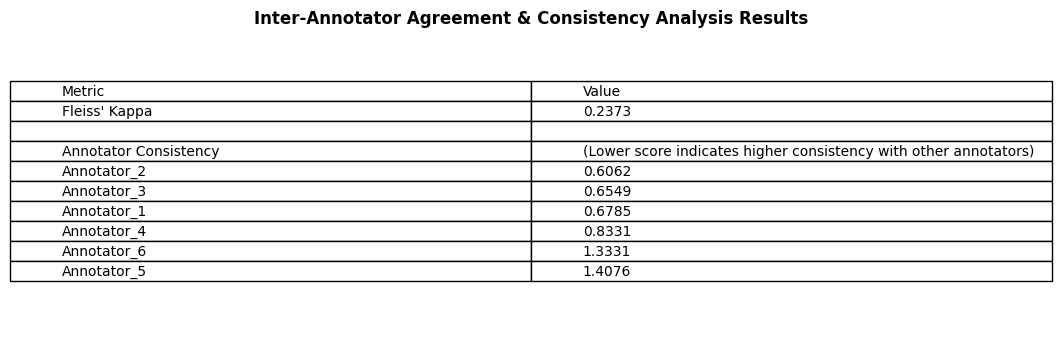

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.inter_rater import fleiss_kappa

# --- 1. CONFIGURATION ---
FILE_PATH = '/content/InclusiveG-EN_1.0.xlsx'
SHEETS = ['Annotator_1', 'Annotator_2', 'Annotator_3', 'Annotator_4', 'Annotator_5', 'Annotator_6']

# --- 2. DATA LOADING & PROCESSING ---
all_frames = []

for name in SHEETS:
    try:
        df = pd.read_excel(FILE_PATH, sheet_name=name)
        df.columns = [c.strip() for c in df.columns]

        # Obtaining the numerical value only
        subset = df[['Output_ID', 'Final_Score_0_15']].copy()
        subset['Annotator'] = name
        # Cleaning non-numerical values in the dataset
        subset['Final_Score_0_15'] = pd.to_numeric(subset['Final_Score_0_15'], errors='coerce')

        all_frames.append(subset)
    except Exception as e:
        print(f"Warning: Could not process {name}. Error: {e}")

master_df = pd.concat(all_frames).dropna(subset=['Final_Score_0_15'])

# --- 3. RELIABILITY ANALYSIS (FLEISS' KAPPA) ---
# Creating a table with 16 columns because there are scores from 0-15.
pivot_scores = master_df.pivot(index='Output_ID', columns='Annotator', values='Final_Score_0_15')
score_range = np.arange(0, 16) #all possible scores from 0 to 15.

counts_matrix = np.zeros((pivot_scores.shape[0], len(score_range)))
for i, row in enumerate(pivot_scores.values):
    for val in row:
        if pd.notnull(val):
            counts_matrix[i, int(val)] += 1

# using all the rows that are annotated by the annotators
ratings_per_row = counts_matrix.sum(axis=1)
max_ratings = int(ratings_per_row.max())
valid_rows = counts_matrix[ratings_per_row == max_ratings]

kappa_score = fleiss_kappa(valid_rows)

# --- 4. CONSISTENCY & DISPUTE ANALYSIS ---
row_mean = pivot_scores.mean(axis=1)
#calculating annotator deviations (lower score equals to higher consistency among anotators)
annotator_deviations = pivot_scores.subtract(row_mean, axis=0).abs().mean().sort_values()
consistency_df = annotator_deviations.reset_index()
consistency_df.columns = ['Annotator', 'Mean_Abs_Deviation']

# --- 5. VISUALIZATION (MATPLOTLIB TABLE) ---
def save_results_table(kappa, consistency_df):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off')

    # Preparing the dataset
    table_data = []
    table_data.append(["Metric", "Value"])
    table_data.append(["Fleiss' Kappa", f"{kappa:.4f}"])
    table_data.append(["", ""]) # for space in the table
    table_data.append(["Annotator Consistency", "(Lower score indicates higher consistency with other annotators)"])

    for _, row in consistency_df.iterrows():
        table_data.append([row['Annotator'], f"{row['Mean_Abs_Deviation']:.4f}"])

    table = ax.table(cellText=table_data, loc='center', cellLoc='left', colWidths=[0.7, 0.7])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)

    plt.title("Inter-Annotator Agreement & Consistency Analysis Results", pad=0, fontweight='bold')
    plt.show()

# --- 6. FINAL PRINT BLOCK (SUMMARY) ---
print(f"{' RAW DATA ANALYSIS SUMMARY ':=^50}")
print(f"Total Evaluated IDs: {len(pivot_scores)}")
print(f"Rows with Full Consensus: {len(valid_rows)}")
print(f"Fleiss' Kappa (0-15 Range): {kappa_score:.4f}")
print("-" * 50)
print("Annotator Consistency Ranking (Mean Absolute Deviation):")
print(consistency_df.to_string(index=False))
print("=" * 50)

# Tabloyu göster
save_results_table(kappa_score, consistency_df)

ADDING CATEGORIZATION METHOD FOR SCORES IN ORDER TO INCREASE FLEISS KAPPA - THE ANNOTATION PLATFORM BEFORE THE MEETING IS USED.

=========== RAW DATA ANALYSIS SUMMARY ============
Total Evaluated IDs: 180
Rows with Full Consensus: 180
Fleiss' Kappa (0-5 Range): 0.4984
--------------------------------------------------
Annotator Consistency Ranking (Mean Absolute Deviation):
  Annotator  Mean_Abs_Deviation
Annotator_2            0.189815
Annotator_1            0.197222
Annotator_3            0.208333
Annotator_4            0.213889
Annotator_5            0.321296
Annotator_6            0.362037


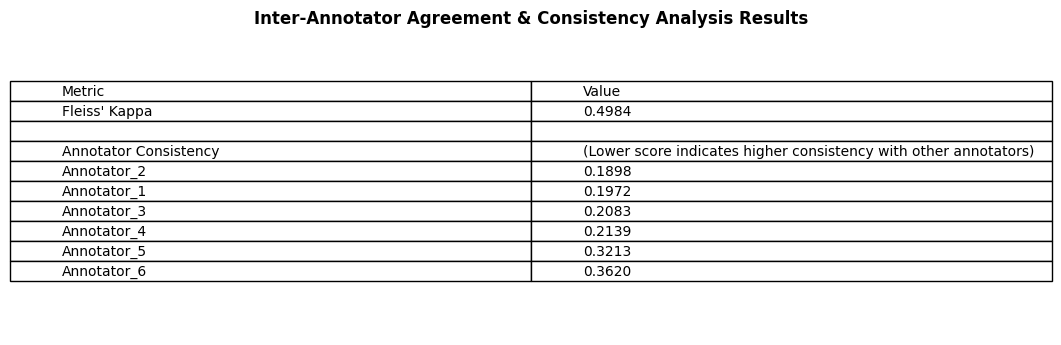

In [ ]:
#ADDING A FUNCTION TO CONVERT 0-15 SYSTEM INTO A 0-5 SYSTEM WITH CATEGORIZATION
def get_category_rank(score):
    try:
        val = float(score) # to make sure the value is a number
    except:
        return np.nan # leaving empty if there is no number

    # the criterias are settled here for categorization
    if val >= 15: return 5          # Fully Inclusive
    elif 11 <= val < 15: return 4   # Highly Inclusive
    elif 7 <= val < 11: return 3    # Moderately Inclusive
    elif 3 <= val < 7: return 2     # Minimally Inclusive
    else: return 1                  # Non-Inclusive
# --- 1. CONFIGURATION ---
FILE_PATH = '/content/InclusiveG-EN_1.0.xlsx'
SHEETS = ['Annotator_1', 'Annotator_2', 'Annotator_3', 'Annotator_4', 'Annotator_5', 'Annotator_6']

# --- 2. DATA LOADING & PROCESSING ---
all_frames = []

for name in SHEETS:
  try:
      df = pd.read_excel(FILE_PATH, sheet_name=name)
      df.columns = [c.strip() for c in df.columns]

      # Obtaining the numerical value only
      subset = df[['Output_ID', 'Final_Score_0_15']].copy()
      subset['Annotator'] = name
      # Cleaning non-numerical values in the dataset
      subset['Final_Score_0_15'] = pd.to_numeric(subset['Final_Score_0_15'], errors='coerce')
      subset['Rank'] = subset['Final_Score_0_15'].apply(get_category_rank)
      all_frames.append(subset)
  except Exception as e:
      print(f"Warning: Could not process {name}. Error: {e}")

master_df = pd.concat(all_frames).dropna(subset=['Final_Score_0_15'])

# --- 3. RELIABILITY ANALYSIS (FLEISS' KAPPA) ---
# Creating a table with 6 columns because there are scores from 0-5.
pivot_scores_2 = master_df.pivot(index='Output_ID', columns='Annotator', values='Rank')
score_range = np.arange(0, 6) #all possible scores from 0 to 6.

counts_matrix = np.zeros((pivot_scores_2.shape[0], len(score_range)))
for i, row in enumerate(pivot_scores_2.values):
    for val in row:
        if pd.notnull(val):
            counts_matrix[i, int(val)] += 1

# using all the rows that are annotated by the annotators
ratings_per_row = counts_matrix.sum(axis=1)
max_ratings = int(ratings_per_row.max())
valid_rows = counts_matrix[ratings_per_row == max_ratings]

kappa_score = fleiss_kappa(valid_rows)

# --- 4. CONSISTENCY & DISPUTE ANALYSIS ---
row_mean = pivot_scores_2.mean(axis=1)
# #calculating annotator deviations (lower score equals to higher consistency among anotators)
annotator_deviations = pivot_scores_2.subtract(row_mean, axis=0).abs().mean().sort_values()
consistency_df = annotator_deviations.reset_index()
consistency_df.columns = ['Annotator', 'Mean_Abs_Deviation']

# --- 5. VISUALIZATION (MATPLOTLIB TABLE) ---
def save_results_table(kappa, consistency_df_1):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off')

    # Preparing the dataset
    table_data = []
    table_data.append(["Metric", "Value"])
    table_data.append(["Fleiss' Kappa", f"{kappa:.4f}"])
    table_data.append(["", ""]) # adding space in between
    table_data.append(["Annotator Consistency", "(Lower score indicates higher consistency with other annotators)"])

    for _, row in consistency_df.iterrows():
        table_data.append([row['Annotator'], f"{row['Mean_Abs_Deviation']:.4f}"])

    table = ax.table(cellText=table_data, loc='center', cellLoc='left', colWidths=[0.7, 0.7])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)

    plt.title("Inter-Annotator Agreement & Consistency Analysis Results", pad=0, fontweight='bold')
    plt.show()

# --- 6. FINAL PRINT BLOCK (SUMMARY) ---
print(f"{' RAW DATA ANALYSIS SUMMARY ':=^50}")
print(f"Total Evaluated IDs: {len(pivot_scores_2)}")
print(f"Rows with Full Consensus: {len(valid_rows)}")
print(f"Fleiss' Kappa (0-5 Range): {kappa_score:.4f}")
print("-" * 50)
print("Annotator Consistency Ranking (Mean Absolute Deviation):")
print(consistency_df.to_string(index=False))
print("=" * 50)

save_results_table(kappa_score, consistency_df)

THE SAME CATEGORIZATION METHOD IS APPLIED, BUT THIS TIME THE NEW EXCEL FILE IS USED (CORRECTED BY THE ALL ANNOTATORS DURING THE MEETING)

=========== RAW DATA ANALYSIS SUMMARY ============
Total Evaluated IDs: 180
Rows with Full Consensus: 180
Fleiss' Kappa (0-5 Range): 0.5509
--------------------------------------------------
Annotator Consistency Ranking (Mean Absolute Deviation):
  Annotator  Mean_Abs_Deviation
Annotator_1            0.180556
Annotator_2            0.195370
Annotator_3            0.200926
Annotator_4            0.213889
Annotator_5            0.237963
Annotator_6            0.299074


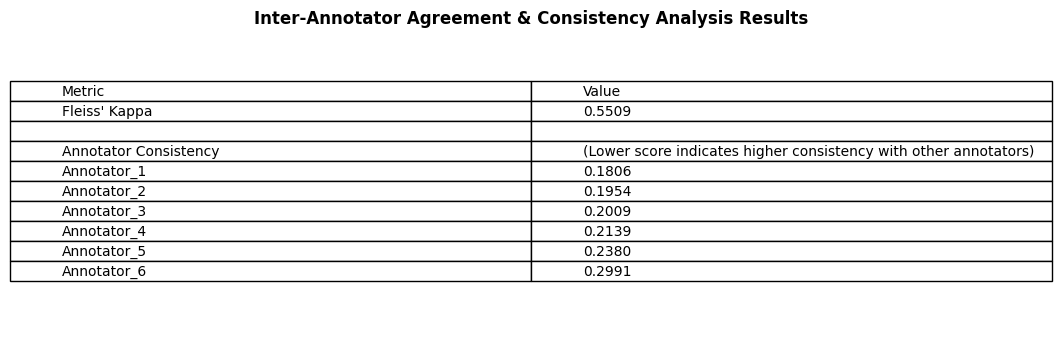

In [ ]:
#ADDING A FUNCTION TO CONVERT 0-15 SYSTEM INTO A 0-5 SYSTEM WITH CATEGORIATION
def get_category_rank(score):
    try:
        val = float(score)
    except:
        return np.nan # Eğer sayı değilse boş bırak


    if val >= 15: return 5          # Fully Inclusive
    elif 11 <= val < 15: return 4   # Highly Inclusive
    elif 7 <= val < 11: return 3    # Moderately Inclusive
    elif 3 <= val < 7: return 2     # Minimally Inclusive
    else: return 1                  # Non-Inclusive
# --- 1. CONFIGURATION ---
FILE_PATH = '/content/InclusiveG-EN_2.0.xlsx'
SHEETS = ['Annotator_1', 'Annotator_2', 'Annotator_3', 'Annotator_4', 'Annotator_5', 'Annotator_6']

# --- 2. DATA LOADING & PROCESSING ---
all_frames = []

for name in SHEETS:
  try:
      df = pd.read_excel(FILE_PATH, sheet_name=name)
      df.columns = [c.strip() for c in df.columns]

      # Obtaining the numerical value only
      subset = df[['Output_ID', 'Final_Score_0_15']].copy()
      subset['Annotator'] = name
      # Cleaning non-numerical values in the dataset
      subset['Final_Score_0_15'] = pd.to_numeric(subset['Final_Score_0_15'], errors='coerce')
      subset['Rank'] = subset['Final_Score_0_15'].apply(get_category_rank)
      all_frames.append(subset)
  except Exception as e:
      print(f"Warning: Could not process {name}. Error: {e}")

master_df = pd.concat(all_frames).dropna(subset=['Final_Score_0_15'])

# --- 3. RELIABILITY ANALYSIS (FLEISS' KAPPA) ---
# Creating a table with 6 columns because there are scores from 0-5.
pivot_scores_3 = master_df.pivot(index='Output_ID', columns='Annotator', values='Rank')
score_range = np.arange(0, 6) #all possible scores from 0 to 6.

counts_matrix = np.zeros((pivot_scores_3.shape[0], len(score_range)))
for i, row in enumerate(pivot_scores_3.values):
    for val in row:
        if pd.notnull(val):
            counts_matrix[i, int(val)] += 1

# using all the rows that are annotated by the annotators
ratings_per_row = counts_matrix.sum(axis=1)
max_ratings = int(ratings_per_row.max())
valid_rows = counts_matrix[ratings_per_row == max_ratings]

kappa_score = fleiss_kappa(valid_rows)

# --- 4. CONSISTENCY & DISPUTE ANALYSIS ---
row_mean = pivot_scores_3.mean(axis=1)
# #calculating annotator deviations (lower score equals to higher consistency among anotators)
annotator_deviations = pivot_scores_3.subtract(row_mean, axis=0).abs().mean().sort_values()
consistency_df = annotator_deviations.reset_index()
consistency_df.columns = ['Annotator', 'Mean_Abs_Deviation']

# --- 5. VISUALIZATION (MATPLOTLIB TABLE) ---
def save_results_table(kappa, consistency_df_1):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off')

    # Preparing the dataset
    table_data = []
    table_data.append(["Metric", "Value"])
    table_data.append(["Fleiss' Kappa", f"{kappa:.4f}"])
    table_data.append(["", ""]) # adding space in between
    table_data.append(["Annotator Consistency", "(Lower score indicates higher consistency with other annotators)"])

    for _, row in consistency_df.iterrows():
        table_data.append([row['Annotator'], f"{row['Mean_Abs_Deviation']:.4f}"])

    table = ax.table(cellText=table_data, loc='center', cellLoc='left', colWidths=[0.7, 0.7])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)

    plt.title("Inter-Annotator Agreement & Consistency Analysis Results", pad=0, fontweight='bold')
    plt.show()

# --- 6. FINAL PRINT BLOCK (SUMMARY) ---
print(f"{' RAW DATA ANALYSIS SUMMARY ':=^50}")
print(f"Total Evaluated IDs: {len(pivot_scores_3)}")
print(f"Rows with Full Consensus: {len(valid_rows)}")
print(f"Fleiss' Kappa (0-5 Range): {kappa_score:.4f}")
print("-" * 50)
print("Annotator Consistency Ranking (Mean Absolute Deviation):")
print(consistency_df.to_string(index=False))
print("=" * 50)

# Tabloyu göster
save_results_table(kappa_score, consistency_df)

Annotator Agreement Heatmap


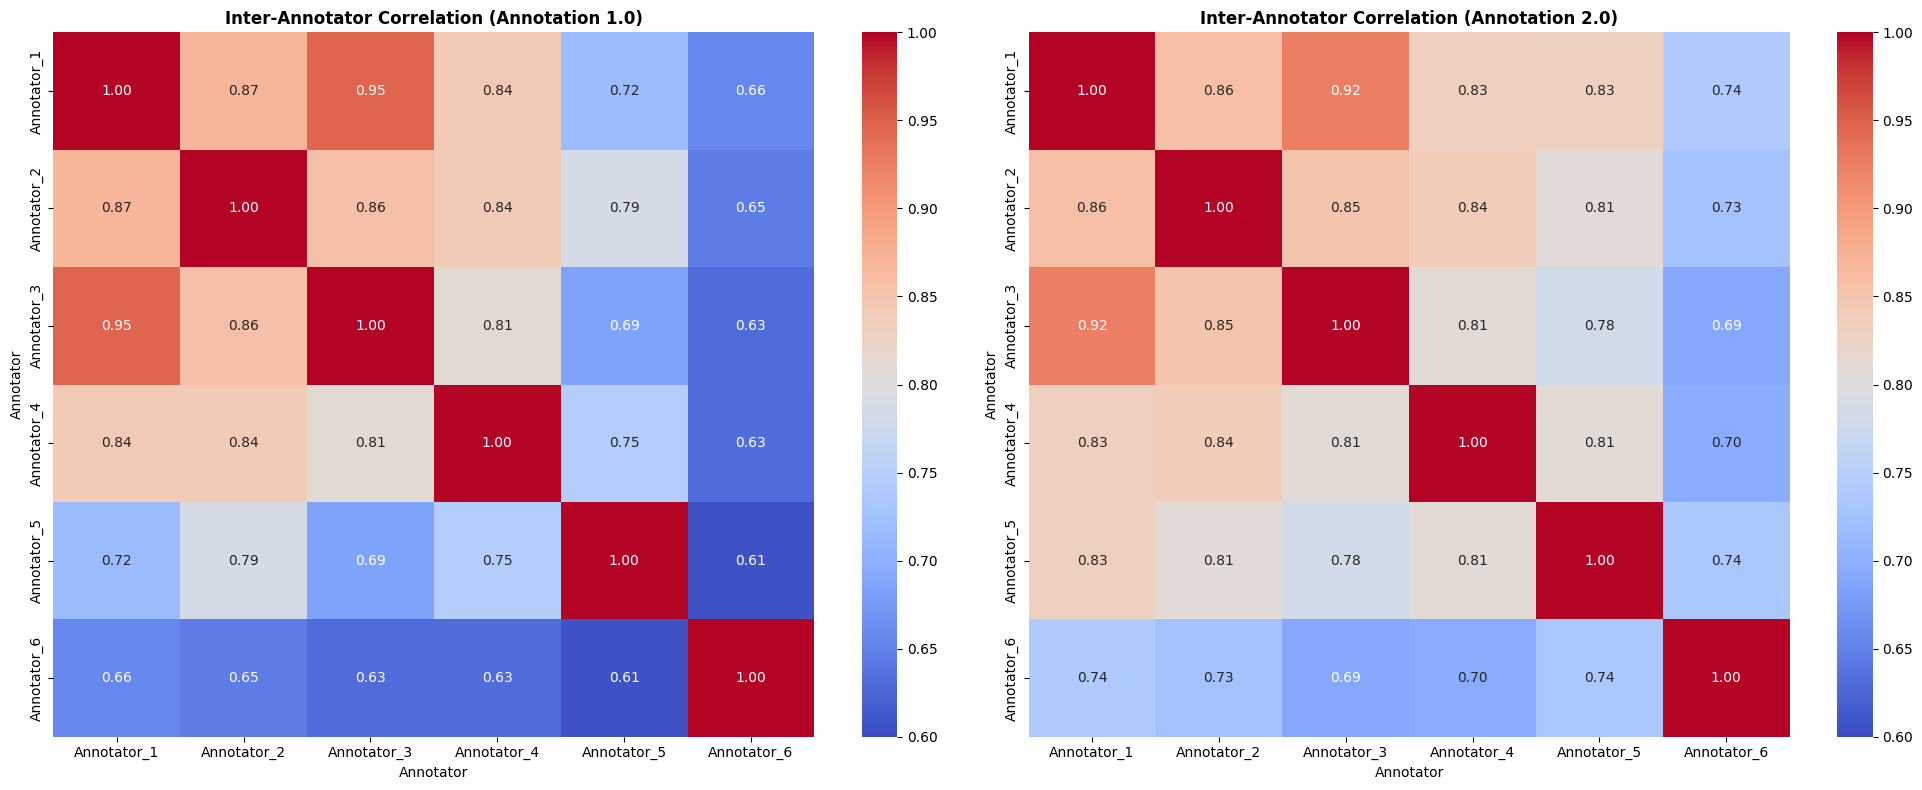

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Annotator Agreement Heatmap ---

def plot_comparative_heatmaps(pivot1, pivot2):
    # Two graphs next to each other (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # 1. Heatmap (Annotation 1.0)
    corr1 = pivot1.corr()
    sns.heatmap(corr1, annot=True, cmap='coolwarm', fmt=".2f", ax=ax1, vmin=0.6, vmax=1)
    ax1.set_title('Inter-Annotator Correlation (Annotation 1.0)', fontweight='bold')

    # 2. Heatmap (Annotation 2.0)
    corr2 = pivot2.corr()
    sns.heatmap(corr2, annot=True, cmap='coolwarm', fmt=".2f", ax=ax2, vmin=0.6, vmax=1)
    ax2.set_title('Inter-Annotator Correlation (Annotation 2.0)', fontweight='bold')

    # Regulate it
    plt.tight_layout()
    plt.show()

# To start the function:
plot_comparative_heatmaps(pivot_scores_2, pivot_scores_3)

3. SD Score vs. Output ID: Bu grafik, hangi veri noktalarında kaos olduğunu gösterir. Tezin için "Görüş Ayrılığı Analizi" kısmında kullanabilirsin.

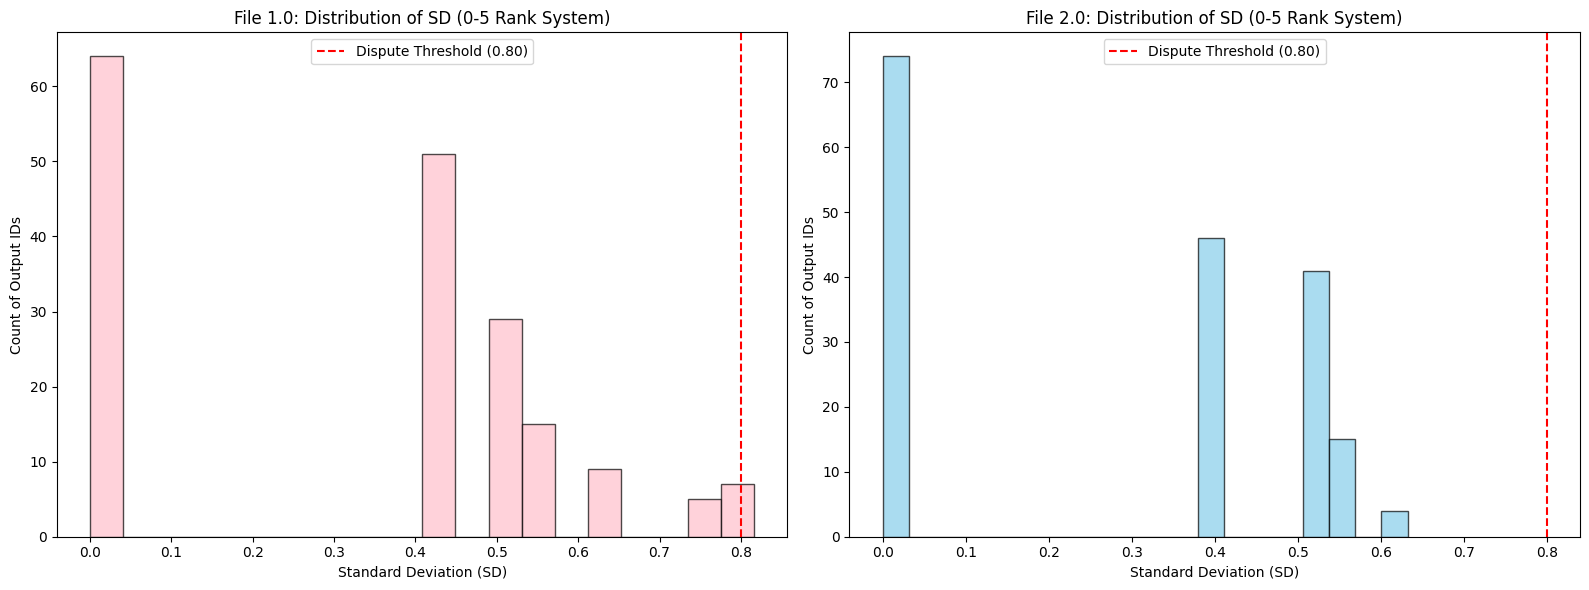

In [ ]:
# --- STANDAR DEVIATION CALCULATIONS (WITH 0-5 CATEGORIZATION) ---

row_std_1 = pivot_scores_2.std(axis=1)
row_std_2 = pivot_scores_3.std(axis=1)

# --- VISUALIZING NEXT TO ONE ANOTHER ---
plt.figure(figsize=(16, 6))

# GRAPH ON THE LEFT (FILE: InclusiveG-EN_1.0.xlsx)
plt.subplot(1, 2, 1)
plt.hist(row_std_1.dropna(), bins=20, color='pink', edgecolor='black', alpha=0.7)
plt.axvline(x=0.80, color='red', linestyle='--', label='Dispute Threshold (0.80)')
plt.title('File 1.0: Distribution of SD (0-5 Rank System)')
plt.xlabel('Standard Deviation (SD)')
plt.ylabel('Count of Output IDs')
plt.legend()

# GRAPH ON THE RIGHT (FILE: InclusiveG-EN_2.0.xlsx)
plt.subplot(1, 2, 2)
plt.hist(row_std_2.dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0.80, color='red', linestyle='--', label='Dispute Threshold (0.80)')
plt.title('File 2.0: Distribution of SD (0-5 Rank System)')
plt.xlabel('Standard Deviation (SD)')
plt.ylabel('Count of Output IDs')
plt.legend()

plt.tight_layout()
plt.show()

THE LIST OF OUTPUTS WHOSE STANDARD DEVIATION SCORE IS HIGHER THAN 0.80 -- WILL BE USED TO BE DISCUSSED FIKIR AYRILIGI IN THE DISCUSSION PART 1.0

In [ ]:
# --- DISPUTE ANALYSIS FOR FILE 1.0 (SD > 0.80) ---

# Filter Output IDs where the Standard Deviation is above the 0.80 threshold
disputes_1 = row_std_1[row_std_1 > 0.60]

# Extract the list of IDs
dispute_ids_1 = disputes_1.index.tolist()

print(f"{' DISPUTE ANALYSIS REPORT (FILE 1.0) ':=^50}")
print(f"Dispute Threshold: 0.60")
print(f"Total Number of Disputes: {len(dispute_ids_1)}")
print("-" * 50)
print(f"Output IDs with High Disagreement (SD > 0.60):")
print(f"{dispute_ids_1}\n")
print("=" * 50)

# Optional: Display as a structured table with SD values
# dispute_df = disputes_1.reset_index()
# dispute_df.columns = ['Output_ID', 'Standard_Deviation']
# print("\nDetailed Dispute Table:")
# print(dispute_df.to_string(index=False))

======= DISPUTE ANALYSIS REPORT (FILE 1.0) =======
Dispute Threshold: 0.60
Total Number of Disputes: 21
--------------------------------------------------
Output IDs with High Disagreement (SD > 0.60):
['M1-S3-F1-T3', 'M1-S3-F1-T4', 'M1-S3-F1-T5', 'M1-S3-F2-T3', 'M1-S3-F2-T5', 'M1-S4-F2-T3', 'M1-S4-F2-T5', 'M1-S6-F1-T1', 'M1-S6-F2-T1', 'M2-S1-F1-T3', 'M2-S1-F1-T4', 'M2-S3-F1-T5', 'M2-S3-F2-T5', 'M2-S4-F2-T1', 'M2-S5-F1-T2', 'M3-S3-F1-T2', 'M3-S3-F1-T3', 'M3-S3-F1-T4', 'M3-S4-F2-T1', 'M3-S4-F2-T5', 'M3-S5-F1-T1']



Tablo 'dispute_report.png' olarak kaydedildi.


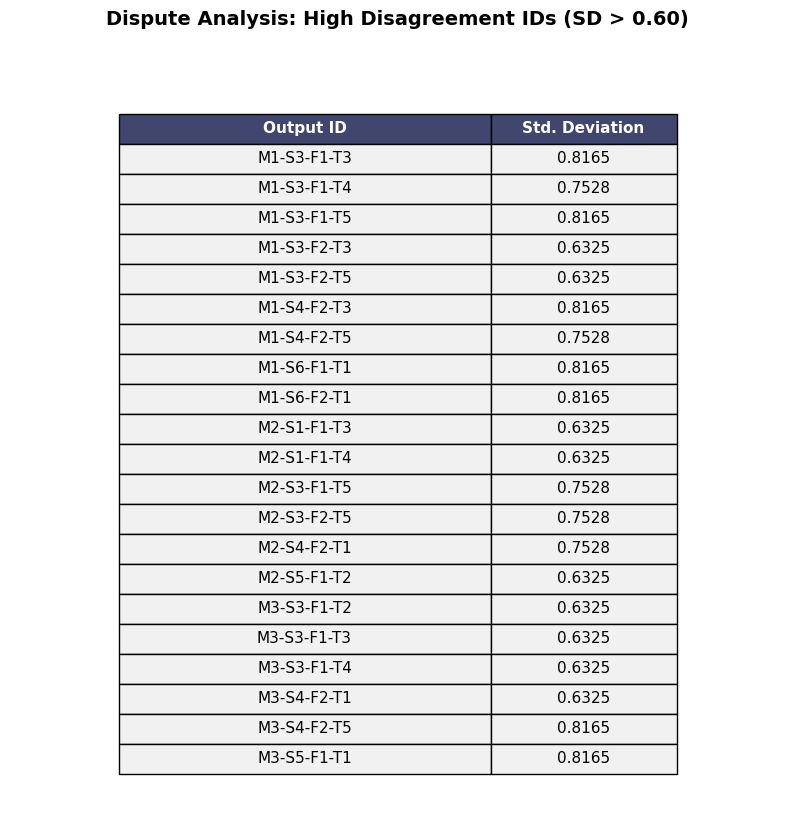

In [ ]:
import matplotlib.pyplot as plt

# --- 5. DISPUTE VISUALIZATION (MATPLOTLIB TABLE) ---
def save_dispute_table(dispute_series):

    table_data = [["Output ID", "Std. Deviation"]]

    top_disputes = dispute_series.head(25)

    for out_id, std_val in top_disputes.items():
        table_data.append([out_id, f"{std_val:.4f}"])

    fig, ax = plt.subplots(figsize=(10, len(table_data) * 0.4 + 1))
    ax.axis('off')


    table = ax.table(cellText=table_data,
                     loc='center',
                     cellLoc='center',
                     colWidths=[0.4, 0.2],
                     cellColours=[['#40466e']*2] + [['#f1f1f2']*2] * (len(table_data)-1))

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.get_text().set_color('white')
            cell.get_text().set_weight('bold')

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)

    plt.title("Dispute Analysis: High Disagreement IDs (SD > 0.60)", fontweight='bold', pad=30, fontsize=14)


    plt.savefig('dispute_report.png', bbox_inches='tight', dpi=300)
    print("Tablo 'dispute_report.png' olarak kaydedildi.")

save_dispute_table(disputes_1)

THE LIST OF OUTPUTS WHOSE STANDARD DEVIATION SCORE IS HIGHER THAN 0.80 -- WILL BE USED TO BE DISCUSSED FIKIR AYRILIGI IN THE DISCUSSION PART 2.0

In [ ]:
# --- DISPUTE ANALYSIS FOR FILE 2.0 (SD > 0.60) ---

# Filter Output IDs where the Standard Deviation is above the 0.60 threshold
disputes_2 = row_std_2[row_std_2 > 0.60]

# Extract the list of IDs
dispute_ids_2 = disputes_2.index.tolist()

print(f"{' DISPUTE ANALYSIS REPORT (FILE 2.0) ':=^50}")
print(f"Dispute Threshold: 0.60")
print(f"Total Number of Disputes: {len(dispute_ids_2)}")
print("-" * 50)
print(f"Output IDs with High Disagreement (SD > 0.60):")
print(dispute_ids_2)
print("=" * 50)

# Optional: Display as a structured table with SD values
# dispute_df = disputes_2.reset_index()
# dispute_df.columns = ['Output_ID', 'Standard_Deviation']
# print("\nDetailed Dispute Table:")
# print(dispute_df.to_string(index=False))

======= DISPUTE ANALYSIS REPORT (FILE 2.0) =======
Dispute Threshold: 0.60
Total Number of Disputes: 4
--------------------------------------------------
Output IDs with High Disagreement (SD > 0.60):
['M1-S3-F2-T3', 'M2-S1-F1-T3', 'M2-S5-F1-T2', 'M3-S3-F1-T2']


THE LIST OF DISAGREED OUTPUT BY ANNOTATORS AND HOW THEY ANNOTATED IT (FOR THE DISCUSSION PART OF THE THESIS)

In [ ]:
# --- DETAILED DISPUTE BREAKDOWN FOR FILE 2.0 (SD > 0.60) ---

# 1. Identify the IDs with SD > 0.60
dispute_mask = row_std_2 > 0.60
dispute_ids = row_std_2[dispute_mask].index

# 2. Filter the pivot table to show only these IDs
# This shows the 1-5 rank given by each annotator
dispute_breakdown = pivot_scores_3.loc[dispute_ids].copy()

# 3. Add the Standard Deviation column to the table for reference
dispute_breakdown['Calculated_SD'] = row_std_2[dispute_mask]

# --- PRINT THE REPORT ---
print(f"{' DETAILED DISPUTE BREAKDOWN (FILE 2.0) ':=^70}")
print(f"Threshold: SD > 0.60")
print(f"Total Disputed Outputs: {len(dispute_breakdown)}")
print("-" * 70)

# Display the table (Annotator scores are in 1-5 Scale)
print(dispute_breakdown.to_string())

print("=" * 70)

# OPTIONAL: Save to CSV if the list is too long to read in the console
# dispute_breakdown.to_csv('dispute_analysis_2.0.csv')

=============== DETAILED DISPUTE BREAKDOWN (FILE 2.0) ================
Threshold: SD > 0.60
Total Disputed Outputs: 4
----------------------------------------------------------------------
Annotator    Annotator_1  Annotator_2  Annotator_3  Annotator_4  Annotator_5  Annotator_6  Calculated_SD
Output_ID                                                                                               
M1-S3-F2-T3            4            4            4            4            3            5       0.632456
M2-S1-F1-T3            3            3            3            3            2            4       0.632456
M2-S5-F1-T2            4            4            3            5            4            4       0.632456
M3-S3-F1-T2            4            4            4            3            4            5       0.632456


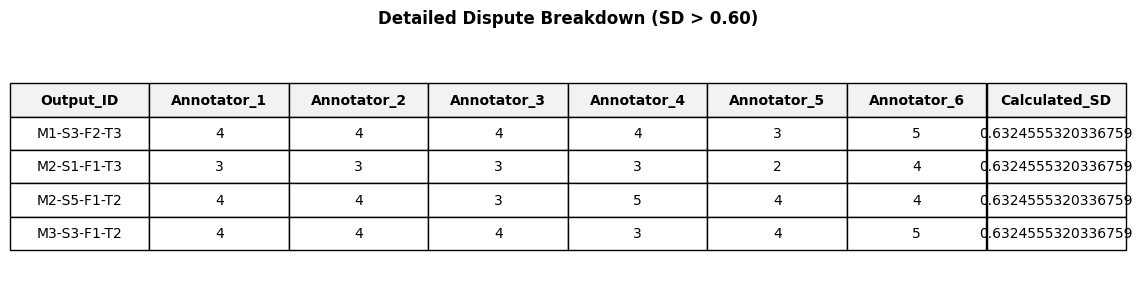

In [ ]:
import matplotlib.pyplot as plt

# --- 2.0 TABLE VISUALIZATION CODE ---

# Resetting the index to make 'Output_ID' a visible column in the table
plot_df = dispute_breakdown.reset_index()

# Setting a dynamic figure size based on the number of rows
fig, ax = plt.subplots(figsize=(12, len(plot_df) * 0.5 + 1))
ax.axis('off')

# Creating the table with Matplotlib
the_table = ax.table(cellText=plot_df.values,
                     colLabels=plot_df.columns,
                     loc='center',
                     cellLoc='center')

# Styling the table: setting font size and scaling rows
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.2, 2)

# Formatting the header row (Bold text and background color)
for (row, col), cell in the_table.get_celld().items():
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_facecolor('#f2f2f2')

plt.title("Detailed Dispute Breakdown (SD > 0.60)", fontweight='bold', pad=20)

# Saving the figure as a high-resolution image
plt.savefig('dispute_detailed_table.png', bbox_inches='tight', dpi=300)
plt.show()